<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
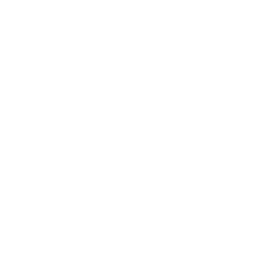
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ομαδοποίηση Τρόπων Αστοχίας στη Μεταποίηση</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Μεταποίηση / Μηχανική Ποιότητας &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη για Στελέχη

Αυτό το παράδειγμα ανακαλύπτει επαναλαμβανόμενους **τρόπους αστοχίας εξοπλισμού** από το πολυδιάστατο προφίλ συμπτωμάτων αισθητήρων που καταγράφεται σε κάθε συμβάν αστοχίας. Οκτώ τυποποιημένες μεταβλητές συμπτωμάτων (κραδασμοί, διαφορά θερμοκρασίας, πτώση πίεσης, αιχμή ρεύματος, θόρυβος, απόκλιση χρόνου κύκλου, διακύμανση ροπής, αριθμός σωματιδίων λαδιού) ομαδοποιούνται με **ιεραρχική ομαδοποίηση πλήρους σύνδεσης** (`PROC CLUSTER METHOD=COMPLETE`), η οποία ευνοεί συμπαγείς, καλά διαχωρισμένες ομάδες. Το `PROC TREE` στη συνέχεια κόβει την ιεραρχία σε **έξι τρόπους αστοχίας**, και το `PROC FREQ` διασταυρώνει αυτούς τους τρόπους με τον τύπο εξοπλισμού και τη βάρδια για να ελέγξει για συστηματικές συσχετίσεις.

Η εκτέλεση εδώ πραγματοποιείται σε ένα **δείγμα 100 συμβάντων** (το περιβάλλον περιορίζει την έξοδο στις 100 παρατηρήσεις). Σε αυτό το δείγμα οι έξι τρόποι είναι περίπου ίσοι σε μέγεθος (n = 16-17 ο καθένας) και διαχωρίζονται κυρίως από υπογραφές **θερμοκρασίας, πίεσης και κραδασμών** παρά από τον τύπο εξοπλισμού — οι διασταυρώσεις τρόπου-ανά-εξοπλισμό και τρόπου-ανά-βάρδια **δεν** είναι στατιστικά σημαντικές σε αυτό το μέγεθος δείγματος (χ-τετράγωνο p = 0.15 και p = 0.07 αντίστοιχα). Η ροή εργασίας κλιμακώνεται αμετάβλητη στο πλήρες ιστορικό συμβάντων, όπου οι μεγαλύτεροι ανά τρόπο αριθμοί θα όξυναν αυτές τις συσχετίσεις.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.FAILURES | Προφίλ συμπτωμάτων συμβάντων αστοχίας εξοπλισμού (συνθετικά) | 100 |
| WORK.FAILURES_STD | Συμπτώματα τυποποιημένα σε μέσο 0, τυπική απόκλιση 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Ιστορικό συγχωνεύσεων πλήρους σύνδεσης (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Τομή έξι τρόπων από `PROC TREE NCLUSTERS=6` | 100 |

*Αυτό το περιβάλλον εκτελείται σε λειτουργία χωρίς άδεια και περιορίζει την έξοδο στις 100 παρατηρήσεις· ο συνθετικός γεννήτορας ζητά 20,000 συμβάντα αλλά διατηρούνται μόνο τα πρώτα 100. Η ανάλυση παρακάτω βασίζεται εξ ολοκλήρου σε αυτό το δείγμα 100 συμβάντων.*

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικών προφίλ συμπτωμάτων συμβάντων αστοχίας
   20.000 συμβάντα αστοχίας σε 50 μονάδες εξοπλισμού
   Σημείωση: οι κωδικοί τύπου εξοπλισμού και βάρδιας διατηρούνται
   σε λατινικούς χαρακτήρες ως κατηγορικές τιμές CLASS/TABLES·
   οι επικεφαλίδες αποδίδονται στα ελληνικά μέσω δηλώσεων LABEL.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.failures;
    CALL streaminit(42);
    ARRAY equip_type_list[4] $12 _temporary_ ('PRESS' 'CONVEYOR' 'ROBOT_ARM' 'FURNACE');
    ARRAY shift_list[3] $8 _temporary_ ('DAY' 'EVENING' 'NIGHT');
    ΕΠΑΝΑΛΗΨΗ event_id = 1 ΕΩΣ 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Προφίλ συμπτωμάτων: 8 μετρήσεις αισθητήρων τη στιγμή της αστοχίας */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        ΕΑΝ vibration_level < 0 ΤΟΤΕ vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        ΕΑΝ current_spike < 0 ΤΟΤΕ current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ equip_num etype_idx shift_idx;
    ΜΟΡΦΗ failure_date date9.;
    LABEL
        equipment_type       = 'Τύπος Εξοπλισμού'
        shift                = 'Βάρδια'
        vibration_level      = 'Επίπεδο Κραδασμών'
        temperature_delta    = 'Διαφορά Θερμοκρασίας (C)'
        pressure_drop        = 'Πτώση Πίεσης'
        current_spike        = 'Αιχμή Ρεύματος'
        noise_db             = 'Θόρυβος (dB)'
        cycle_time_deviation = 'Απόκλιση Χρόνου Κύκλου'
        torque_variance      = 'Διακύμανση Ροπής'
        oil_particle_count   = 'Αριθμός Σωματιδίων Λαδιού'
        downtime_minutes     = 'Χρόνος Εκτός Λειτουργίας (λεπτά)';
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.28 seconds
  cpu   6.28 seconds


---

In [2]:
/* --------------------------------------------------------
   Βασικές κατανομές συμπτωμάτων ανά τύπο εξοπλισμού
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.failures n mean std MAX;
    ΚΛΑΣΗ equipment_type;
    ΜΕΤΑΒΛΗΤΗ vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    LABEL equipment_type       = 'Τύπος Εξοπλισμού'
          vibration_level      = 'Επίπεδο Κραδασμών'
          temperature_delta    = 'Διαφορά Θερμοκρασίας (C)'
          pressure_drop        = 'Πτώση Πίεσης'
          current_spike        = 'Αιχμή Ρεύματος'
          noise_db             = 'Θόρυβος (dB)'
          torque_variance      = 'Διακύμανση Ροπής'
          oil_particle_count   = 'Αριθμός Σωματιδίων Λαδιού';
    TITLE 'Προφίλ Συμπτωμάτων Αστοχίας ανά Τύπο Εξοπλισμού';
ΕΚΤΕΛΕΣΗ;

                                    Προφίλ Συμπτωμάτων Αστοχίας ανά Τύπο Εξοπλισμού                                     

                                                  The MEANS Procedure

                         Analysis Variable : vibration_level Επίπεδο Κραδασμών

        Τύπος Εξοπλισμού                         N Obs           Mean        Std Dev        Maximum
        -------------------------------------------------------------------------------------------
        CONVEYOR                                    19      3.8089474      1.8662437      9.0400000
        FURNACE                                     26      4.3638462      2.0371177     10.1400000
        PRESS                                       30      4.6273333      2.1610740      9.9400000
        ROBOT_ARM                                   25      3.5320000      1.9296070      6.7900000
        -------------------------------------------------------------------------------------------

                   Analysi


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Προφίλ Συμπτωμάτων Αστοχίας ανά Τύπο Εξοπλισμού                                     




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


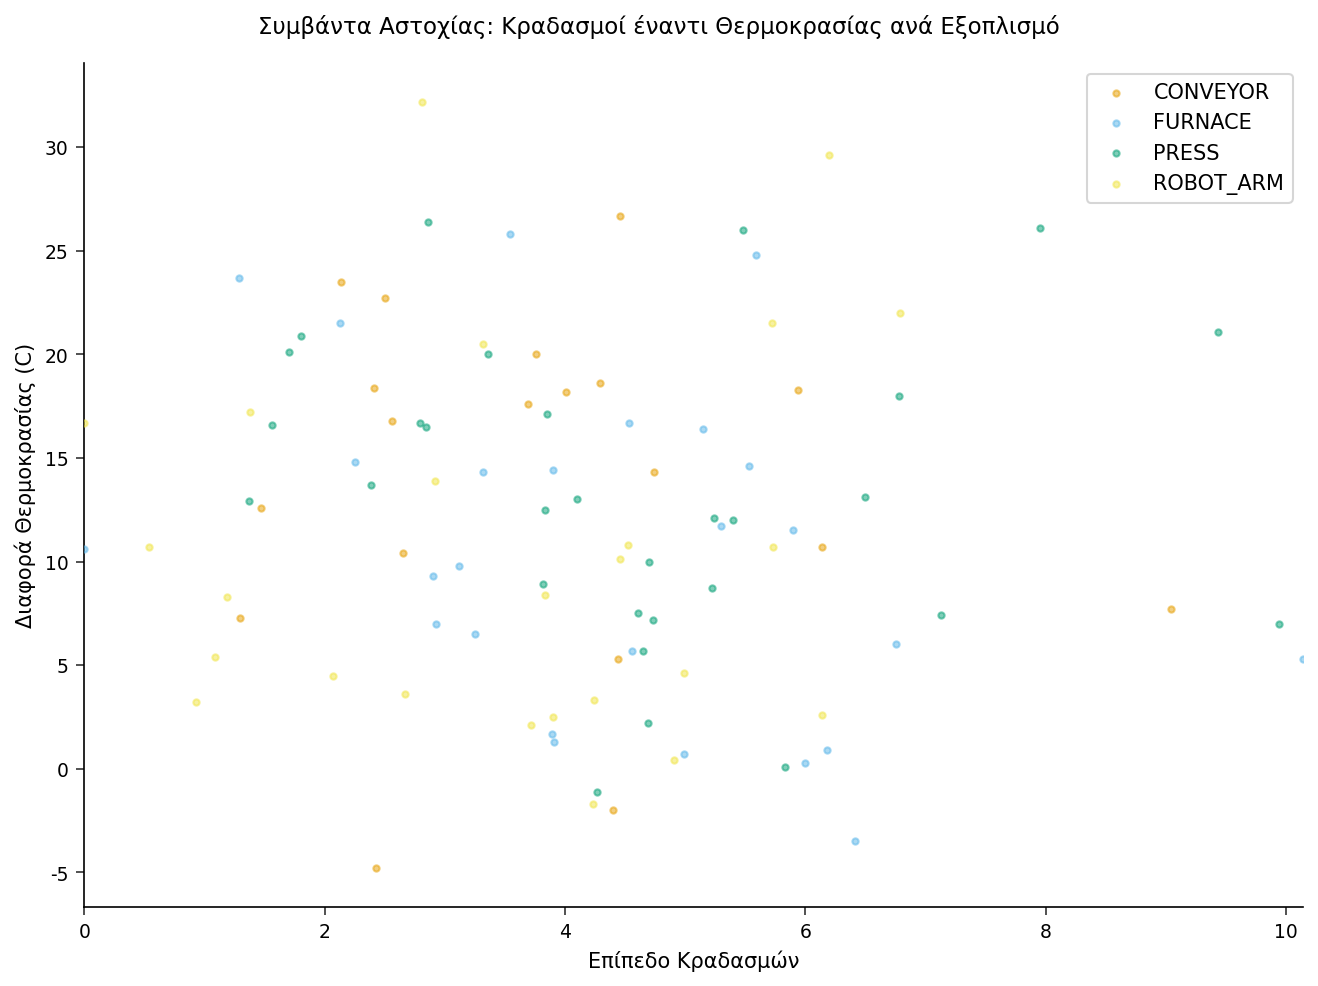

In [3]:
/* --------------------------------------------------------
   Κραδασμοί έναντι Διαφοράς Θερμοκρασίας ανά τύπο εξοπλισμού
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS ΕΤΙΚΕΤΑ='Επίπεδο Κραδασμών';
    YAXIS ΕΤΙΚΕΤΑ='Διαφορά Θερμοκρασίας (C)';
    TITLE 'Συμβάντα Αστοχίας: Κραδασμοί έναντι Θερμοκρασίας ανά Εξοπλισμό';
ΕΚΤΕΛΕΣΗ;

---

In [4]:
/* --------------------------------------------------------
   Τυποποίηση μεταβλητών συμπτωμάτων για ομαδοποίηση
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ STANDARD ΔΕΔΟΜΕΝΑ=work.failures out=work.failures_std
    mean=0 std=1;
    ΜΕΤΑΒΛΗΤΗ vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                    Προφίλ Συμπτωμάτων Αστοχίας ανά Τύπο Εξοπλισμού                                     

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


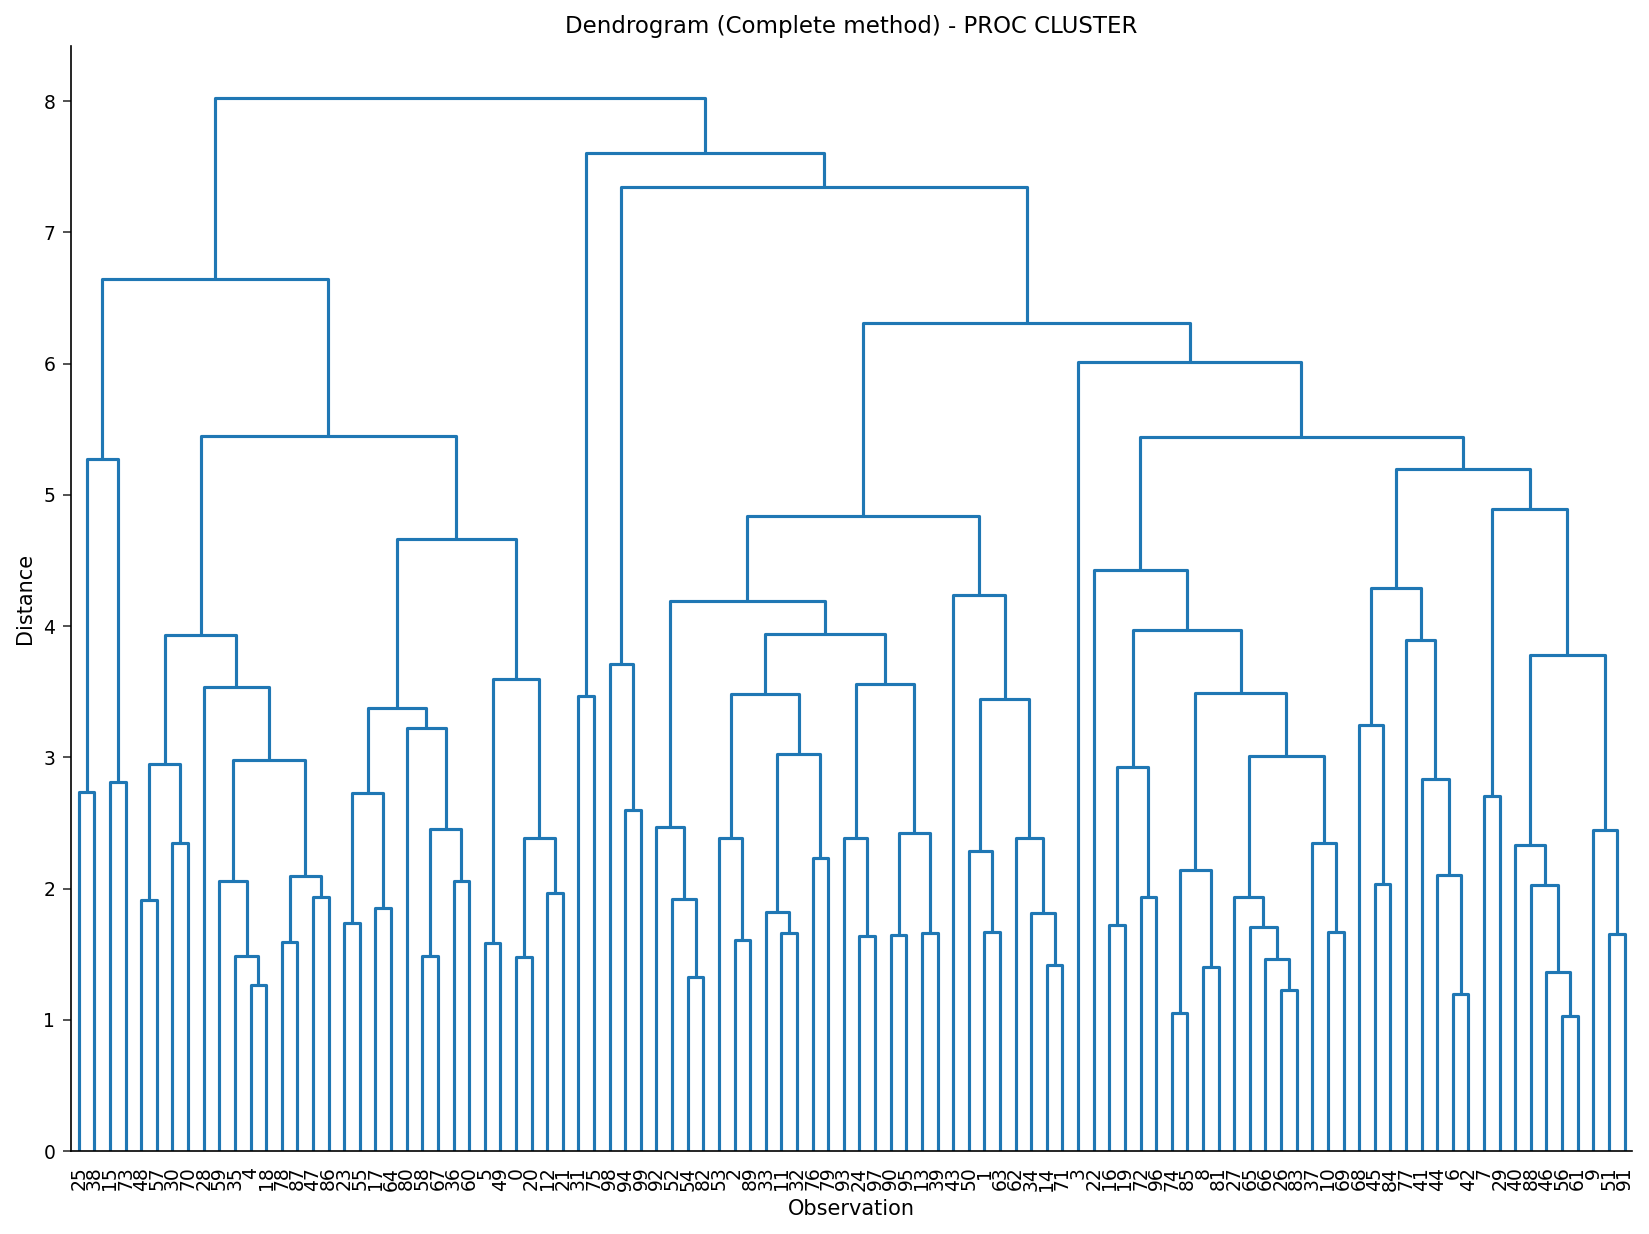

In [5]:
/* --------------------------------------------------------
   Ομαδοποίηση πλήρους σύνδεσης με TRIM= για αφαίρεση
   ακραίων τιμών. Το TRIM=5 αφαιρεί το 5% των πιο
   απομακρυσμένων παρατηρήσεων πριν τον σχηματισμό ομάδων.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ CLUSTER ΔΕΔΟΜΕΝΑ=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo ΕΚΤΥΠΩΣΗ=20 trim=5;
    ΜΕΤΑΒΛΗΤΗ vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
ΕΚΤΕΛΕΣΗ;

In [6]:
/* --------------------------------------------------------
   Κοπή της ιεραρχίας πλήρους σύνδεσης σε έξι τρόπους
   αστοχίας με το PROC TREE (NCLUSTERS=6). Το έξι επιλέγεται
   ως πρακτική, ερμηνεύσιμη διακριτότητα για διαλογή· το
   δενδρόγραμμα παραπάνω δείχνει τη δομή συγχωνεύσεων που
   διαμερίζει αυτή η κοπή.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ TREE ΔΕΔΟΜΕΝΑ=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
ΕΚΤΕΛΕΣΗ;

                                    Προφίλ Συμπτωμάτων Αστοχίας ανά Τύπο Εξοπλισμού                                     




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Συγχώνευση αναθέσεων και προφίλ τρόπων αστοχίας
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.failures_classified;
    ΣΥΓΧΩΝΕΥΣΗ work.failures
          work.failure_mode_assignments(RENAME=(CLUSTER=failure_mode));
    ΚΑΤΑ failure_id;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.failures_classified n mean std;
    ΚΛΑΣΗ failure_mode;
    ΜΕΤΑΒΛΗΤΗ vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    LABEL failure_mode         = 'Τρόπος Αστοχίας'
          vibration_level      = 'Επίπεδο Κραδασμών'
          temperature_delta    = 'Διαφορά Θερμοκρασίας (C)'
          pressure_drop        = 'Πτώση Πίεσης'
          current_spike        = 'Αιχμή Ρεύματος'
          noise_db             = 'Θόρυβος (dB)'
          torque_variance      = 'Διακύμανση Ροπής'
          oil_particle_count   = 'Αριθμός Σωματιδίων Λαδιού'
          downtime_minutes     = 'Χρόνος Εκτός Λειτουργίας (λεπτά)';
    TITLE 'Προφίλ Συμπτωμάτων Τρόπων Αστοχίας (k=6)';
ΕΚΤΕΛΕΣΗ;

                                        Προφίλ Συμπτωμάτων Τρόπων Αστοχίας (k=6)                                        

                                                  The MEANS Procedure

                         Analysis Variable : vibration_level Επίπεδο Κραδασμών

        Τρόπος Αστοχίας                        N Obs           Mean        Std Dev
        --------------------------------------------------------------------------
        1                                         17      4.3470588      2.6168582
        2                                         17      4.2552941      2.2610427
        3                                         17      3.6870588      1.8669720
        4                                         17      4.0500000      2.0351843
        5                                         16      3.4793750      1.4636870
        6                                         16      4.9693750      1.6907177
        -------------------------------------------------------


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                   Κατανομή Τρόπων Αστοχίας ανά Εξοπλισμό και Βάρδια                                    

                                                   The FREQ Procedure

Table of Τρόπος Αστοχίας by Τύπος Εξοπλισμού

Τρόπος Αστοχίας               |  CONVEYOR |   FURNACE |     PRESS | ROBOT_ARM |      Total
------------------------------+-----------+-----------+-----------+-----------+-----------
1                             |         4 |         5 |         7 |         1 |         17
------------------------------+-----------+-----------+-----------+-----------+-----------
2                             |         3 |         5 |         2 |         7 |         17
------------------------------+-----------+-----------+-----------+-----------+-----------
3                             |         6 |         5 |         2 |         4 |         17
------------------------------+-----------+-----------+-----------+-----------+-----------
4                             |  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


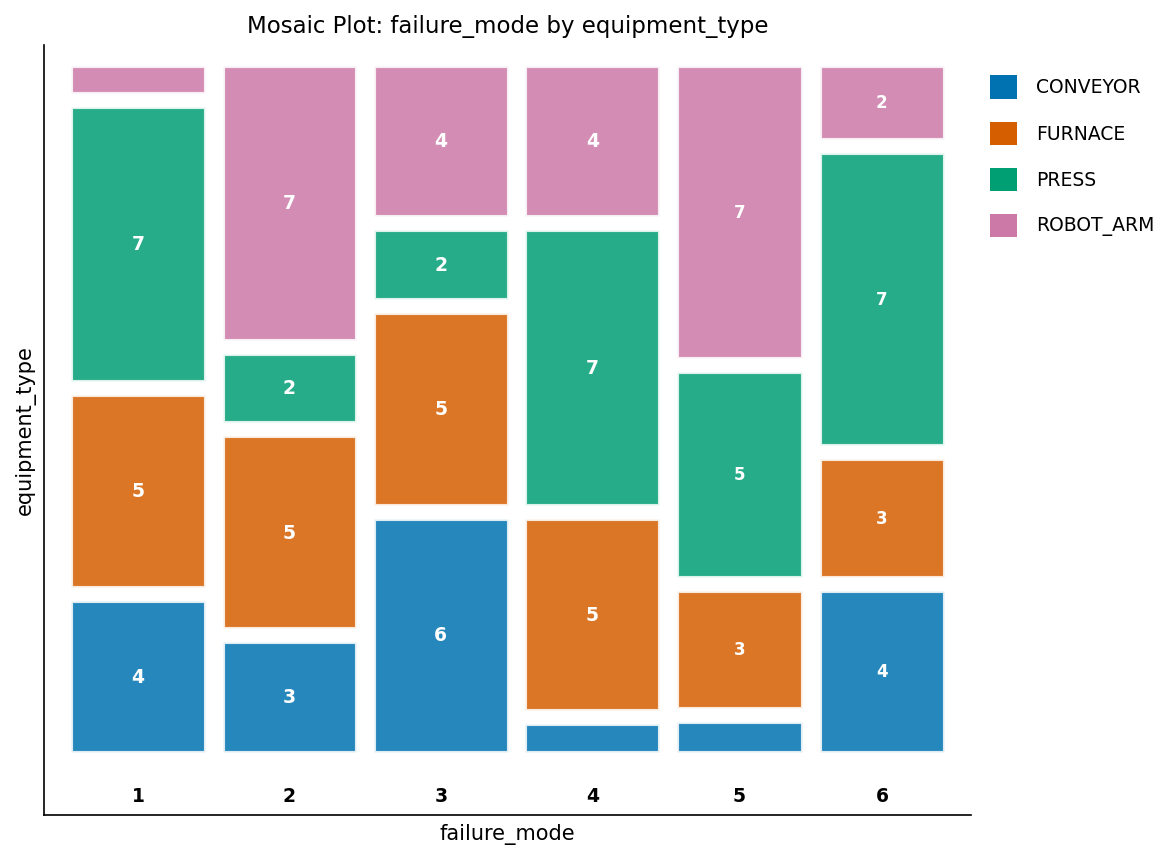

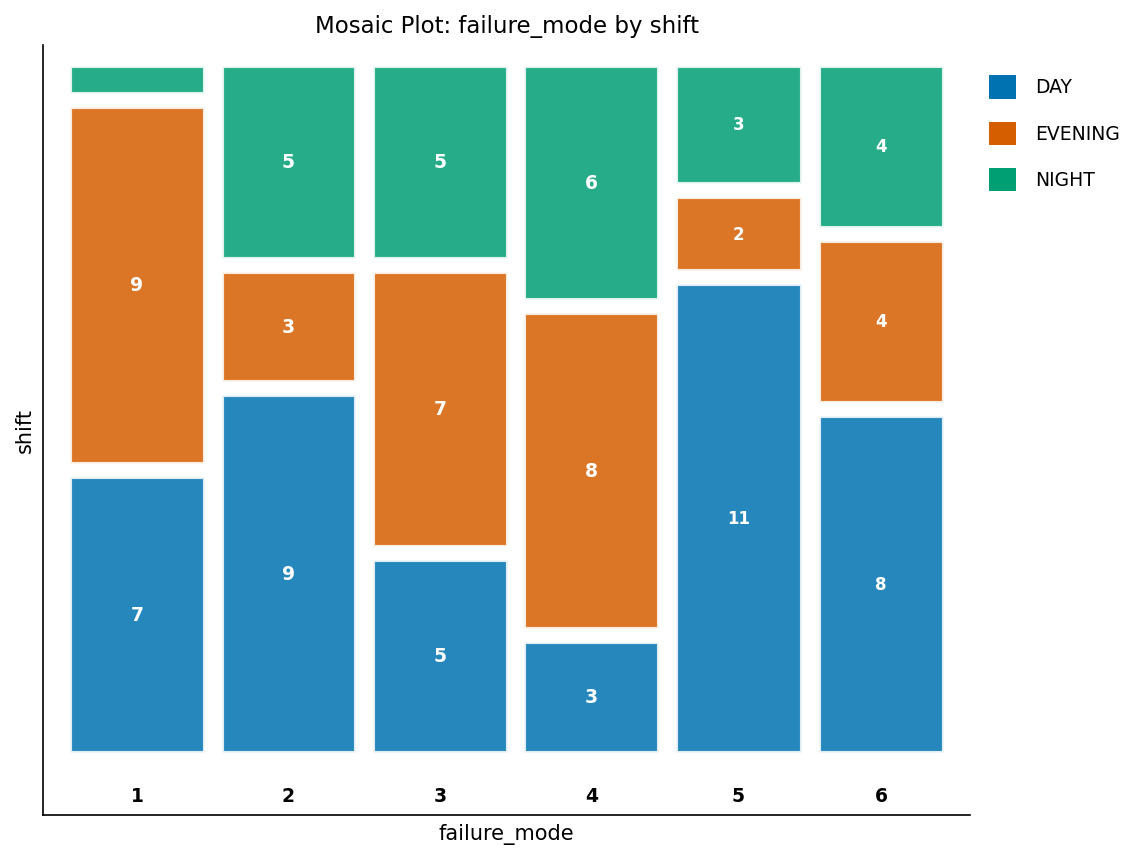

In [8]:
/* --------------------------------------------------------
   Διασταύρωση τρόπων αστοχίας ανά τύπο εξοπλισμού
   και βάρδια για τον εντοπισμό συστηματικών προτύπων
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    LABEL failure_mode   = 'Τρόπος Αστοχίας'
          equipment_type = 'Τύπος Εξοπλισμού'
          shift          = 'Βάρδια';
    TITLE 'Κατανομή Τρόπων Αστοχίας ανά Εξοπλισμό και Βάρδια';
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

Η ομαδοποίηση πλήρους σύνδεσης των 100 τυποποιημένων συμβάντων αστοχίας αποδίδει **έξι τρόπους αστοχίας** σχεδόν ίσου μεγέθους (n = 17, 17, 17, 17, 16, 16). Οι τρόποι διακρίνονται από τις υπογραφές συμπτωμάτων τους στο προφίλ `PROC MEANS` παραπάνω:

- Ο **Τρόπος 6** φέρει τη βαρύτερη υπογραφή μηχανικής καταπόνησης: υψηλότερους μέσους κραδασμούς (4.97), υψηλότερη πτώση πίεσης (7.51) και υψηλότερη αιχμή ρεύματος (1.61) — αλλά τη **χαμηλότερη** διακύμανση ροπής (1.28).
- Ο **Τρόπος 3** είναι ο θερμικός τρόπος: υψηλότερη διαφορά θερμοκρασίας (16.3 C) με τον χαμηλότερο μέσο θόρυβο (73.0 dB).
- Ο **Τρόπος 2** έχει τον **μεγαλύτερο χρόνο εκτός λειτουργίας** με μεγάλη διαφορά (μέσος 85.6 λεπτά έναντι 31-52 για τους άλλους τρόπους) και αυξημένη διακύμανση ροπής (3.57), υποδεικνύοντας συμβάντα με μεγαλύτερο κόστος αποκατάστασης.
- Ο **Τρόπος 4** είναι ο ηπιότερος: χαμηλότερος χρόνος εκτός λειτουργίας (31.4 λεπτά) και κάτω του μέσου πτώση πίεσης και αριθμός σωματιδίων λαδιού.
- Οι **Τρόποι 1 και 5** είναι ομάδες μεικτών συμπτωμάτων χωρίς κανέναν μεμονωμένο κυρίαρχο παράγοντα.

Οι διασταυρώσεις `PROC FREQ` ελέγχουν αν αυτοί οι τρόποι συγκεντρώνονται σε συγκεκριμένο εξοπλισμό ή βάρδιες. Σε αυτό το μέγεθος δείγματος **δεν** το κάνουν: ο τρόπος-ανά-τύπο-εξοπλισμού δίνει χ-τετράγωνο = 20.48 (15 βαθμοί ελευθερίας, p = 0.154, V του Cramer = 0.26) και ο τρόπος-ανά-βάρδια δίνει χ-τετράγωνο = 17.13 (10 βαθμοί ελευθερίας, p = 0.072, V του Cramer = 0.29) — και τα δύο πάνω από το κατώφλι 0.05, και πάνω από το 80% των κελιών έχουν αναμενόμενους αριθμούς κάτω του 5, οπότε το ίδιο το χ-τετράγωνο είναι μόνο ενδεικτικό. Οι ορατές κλίσεις (ο Τρόπος 6 να γέρνει προς PRESS, ο Τρόπος 5 προς τη βάρδια ημέρας) είναι περιγραφικές παρά σημαντικές εδώ.

**Συμπέρασμα:** η πλήρης σύνδεση σε τυποποιημένα προφίλ συμπτωμάτων παράγει μια ερμηνεύσιμη ταξινομία έξι τρόπων με άξονα τη θερμοκρασία, την πίεση και τον χρόνο εκτός λειτουργίας. Για να επιβεβαιωθεί αν οι τρόποι αντιστοιχούν σε συγκεκριμένο εξοπλισμό ή βάρδιες — το αξιοποιήσιμο ερώτημα ριζικής αιτίας — η ανάλυση χρειάζεται το πλήρες ιστορικό συμβάντων παρά αυτό το δείγμα 100 συμβάντων, όπου οι διασταυρώσεις παραμένουν υποϊσχυρές.

---

In [9]:
/* --------------------------------------------------------
   Εξαγωγή ταξινομήσεων αστοχίας για ενσωμάτωση σε CMMS
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>